## Réplica del Artículo 3: *Anomaly Detection in Electrical Systems Using Machine Learning and Statistical Analysis*

# Fase 1: Carga del dataset y análisis exploratorio inicial
Lo primero es cargar los datos, inspeccionar su estructura y visualizar el estado inicial (distribuciones, correlaciones, presencia de valores atípicos). Esto es justo lo que se hace en la sección 2 del artículo (Data preprocessing and visualization).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ipywidgets as widgets
import tempfile
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Descarga el dataset desde Kaggle:
# https://www.kaggle.com/datasets/jaison14/electrical-fault-detection-and-classification
# Usar el directorio content de Colab
BASE_DIR = "/content"
UPLOAD_DIR = os.path.join(BASE_DIR, "archivos_subidos")


# Widget para subir archivos
uploader = widgets.FileUpload(
    accept='*',
    multiple=True,
    description='Upload Files'
)
output = widgets.Output()

def on_upload_change(change):
    with output:
        clear_output(wait=True)

        if not uploader.value:
            print("No hay archivos seleccionados.")
            return

        # Crear la carpeta (y todos los padres) sin errores si ya existe
        os.makedirs(UPLOAD_DIR, exist_ok=True)
        print(f"Carpeta lista: {UPLOAD_DIR}")

        # Guardar (o sobrescribir) los archivos
        for filename, file_info in uploader.value.items():
            content = file_info['content']
            file_path = os.path.join(UPLOAD_DIR, filename)
            with open(file_path, 'wb') as f:
                f.write(content)
            print(f" {filename} guardado en {file_path}")


        os.chdir(UPLOAD_DIR)
        print(f"Directorio actual cambiado a: {os.getcwd()}")
        # Mostrar solo los archivos cargados
        print("\nArchivos subidos:")
        for filename in uploader.value.keys():
            ruta_completa = os.path.join(UPLOAD_DIR, filename)
            print(f"- El archivo: {filename} \n  Se encuentra en la ruta: -> {ruta_completa}")


uploader.observe(on_upload_change, names='value')

display(uploader)
display(output)

FileUpload(value={}, accept='*', description='Upload Files', multiple=True)

Output()

In [ ]:
# Cargar datos (ajusta la ruta si es necesario)
df = pd.read_csv('detect_dataset.csv')

# Ver primeras filas
print("Primeras 5 filas:")
print(df.head())

# Información general
print("\nInformación del dataset:")
print(df.info())

# Estadísticas básicas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Distribución de la variable objetivo
print("\nDistribución de 'Output (S)':")
print(df['Output (S)'].value_counts(normalize=True))

Primeras 5 filas:
   Output (S)          Ia        Ib          Ic        Va        Vb        Vc  \
0           0 -170.472196  9.219613  161.252583  0.054490 -0.659921  0.605431   
1           0 -122.235754  6.168667  116.067087  0.102000 -0.628612  0.526202   
2           0  -90.161474  3.813632   86.347841  0.141026 -0.605277  0.464251   
3           0  -79.904916  2.398803   77.506112  0.156272 -0.602235  0.445963   
4           0  -63.885255  0.590667   63.294587  0.180451 -0.591501  0.411050   

   Unnamed: 7  Unnamed: 8  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12001 entries, 0 to 12000
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Output (S)  12001 non-null  int64  
 1   Ia          12001 non-null  float64
 2   Ib          12001 non-nu

Visualización del estado inicial (sin preprocesar)

Generaremos:

Histogramas de todas las variables numéricas.

Boxplots para detectar outliers, separados por clase (normal vs anomalía).

Matriz de correlación (como la Figura 1 del artículo, aunque ellos mostraban un heatmap de correlaciones).

Distribución de la variable objetivo (balance de clases).

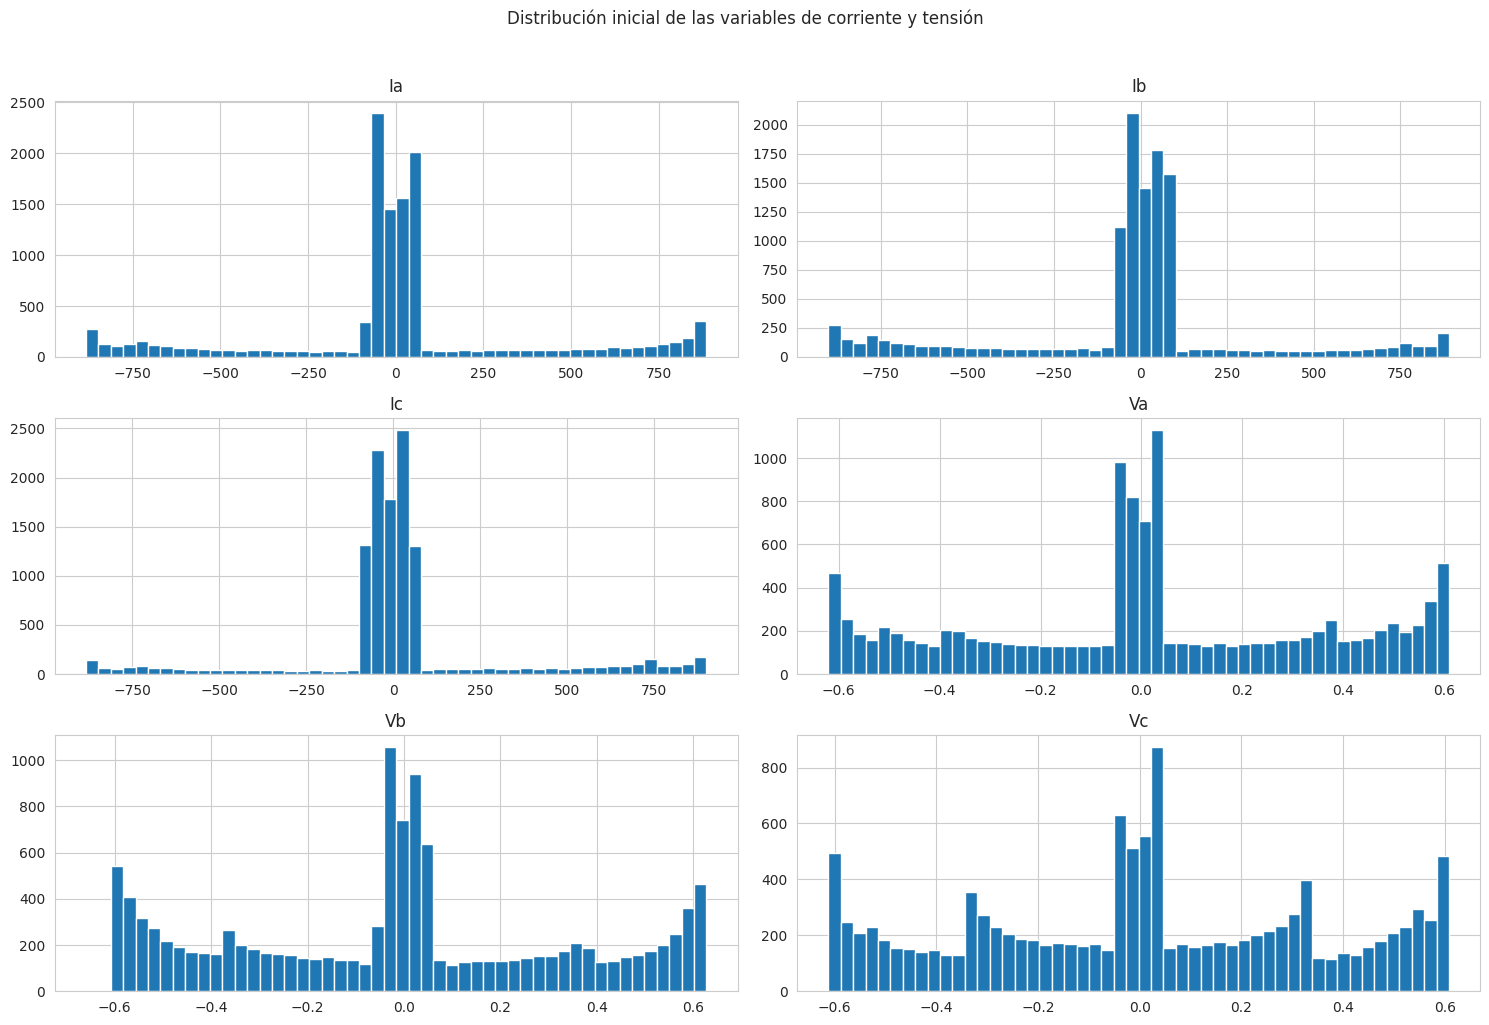

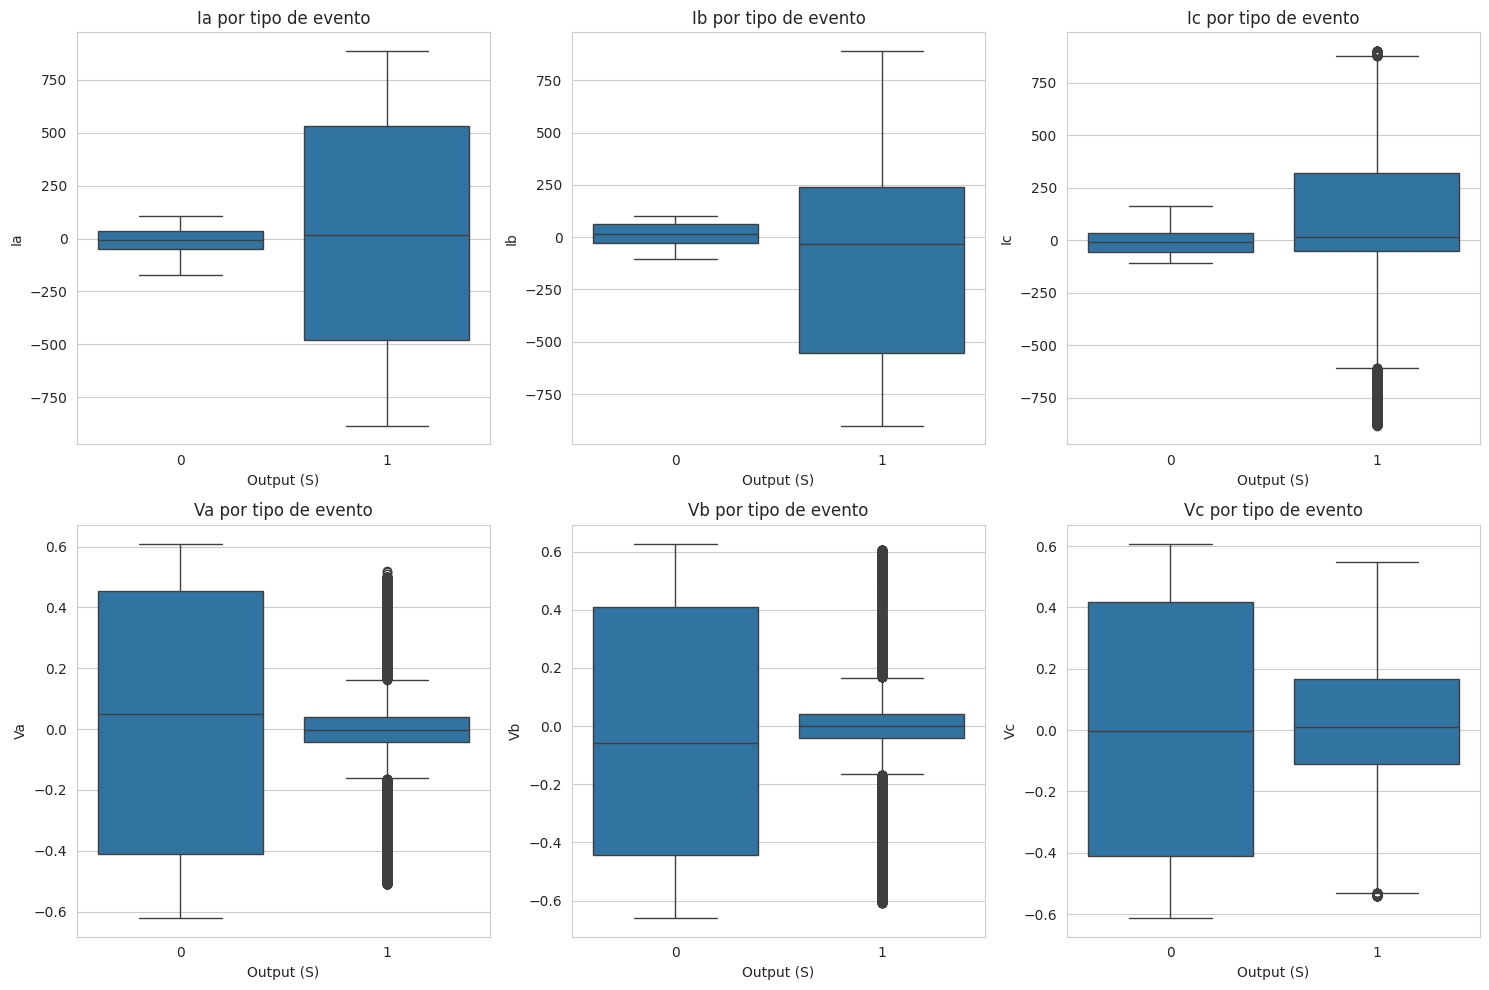

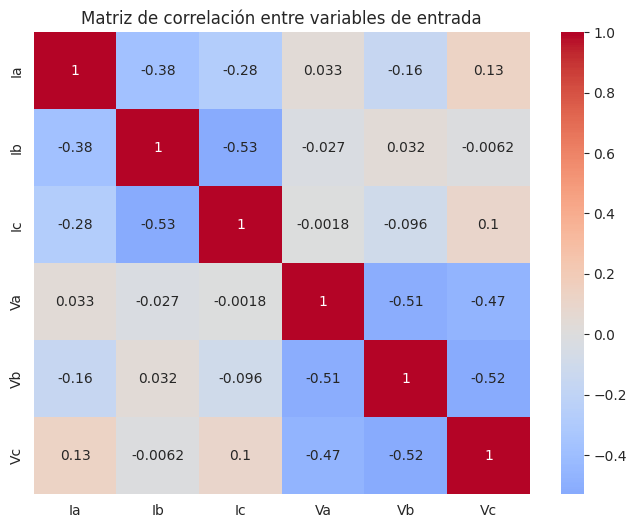

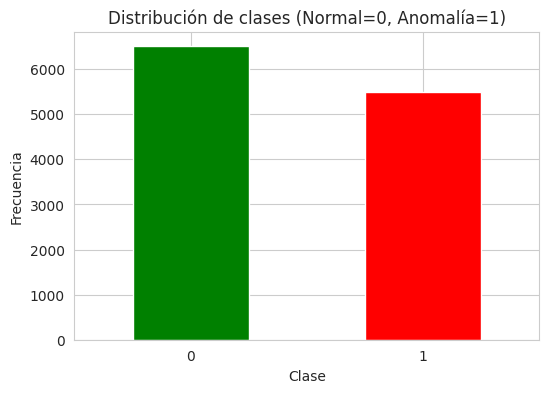

In [ ]:
# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Histogramas de todas las features
features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
df[features].hist(bins=50, figsize=(15, 10))
plt.suptitle('Distribución inicial de las variables de corriente y tensión', y=1.02)
plt.tight_layout()
plt.show()

# Boxplots por clase
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(features):
    sns.boxplot(x='Output (S)', y=col, data=df, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col} por tipo de evento')
plt.tight_layout()
plt.show()

# Matriz de correlación (sin la variable objetivo)
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables de entrada')
plt.show()

# Balance de clases
plt.figure(figsize=(6, 4))
df['Output (S)'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribución de clases (Normal=0, Anomalía=1)')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

# fase 2: limpieza, normalización y division de los datos (Train y Test)


Tal como se describe en el artículo (sección 2.1), aplicaremos:

Eliminación de outliers mediante el rango intercuartil (IQR) para cada variable numérica.

Estandarización (StandardScaler) para que todas las características tengan media 0 y desviación estándar 1.

División en entrenamiento (80%) y prueba (20%) con estratificación para mantener el balance de clases.

In [ ]:
# =============================================
# PREPROCESAMIENTO CON IQR FACTOR 5.0 (MUY SUAVE)
# =============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Limpieza inicial: eliminar columnas vacías
df_clean = df.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# 2. Separar X e y
X = df_clean.drop('Output (S)', axis=1)
y = df_clean['Output (S)']

print("="*60)
print("PREPROCESAMIENTO CON IQR FACTOR 5.0")
print("="*60)
print(f"Muestras originales: {len(X)}")
print(f"Distribución original:\n{y.value_counts(normalize=True)}")

# 3. Eliminación de outliers con IQR factor 5.0
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 5.0 * IQR
upper = Q3 + 5.0 * IQR

# Máscara: filas que están dentro de los límites en TODAS las columnas
mask = ((X >= lower) & (X <= upper)).all(axis=1)

X_clean = X[mask]
y_clean = y[mask]

print(f"\nMuestras eliminadas: {len(X) - len(X_clean)} ({((len(X)-len(X_clean))/len(X)*100):.2f}%)")
print(f"Muestras restantes: {len(X_clean)}")
print(f"Nueva distribución:\n{y_clean.value_counts(normalize=True)}")

# 4. División 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print(f"\nTamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba: {X_test.shape[0]} muestras")

# 5. Escalado estándar (fit solo en train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Escalado completado.")
print(f"Dimensiones finales: X_train_scaled {X_train_scaled.shape}, X_test_scaled {X_test_scaled.shape}")

PREPROCESAMIENTO CON IQR FACTOR 5.0
Muestras originales: 12001
Distribución original:
Output (S)
0    0.542038
1    0.457962
Name: proportion, dtype: float64

Muestras eliminadas: 3946 (32.88%)
Muestras restantes: 8055
Nueva distribución:
Output (S)
0    0.807573
1    0.192427
Name: proportion, dtype: float64

Tamaño entrenamiento: 6444 muestras
Tamaño prueba: 1611 muestras

✅ Escalado completado.
Dimensiones finales: X_train_scaled (6444, 6), X_test_scaled (1611, 6)


# Configuración de Modelos y Preprocesamiento
## Réplica del artículo: *Anomaly Detection in Electrical Systems Using Machine Learning and Statistical Analysis*

---

## 1. Preprocesamiento de Datos
*(Basado en la Sección 2.1 del artículo)*

| Técnica | Configuración Aplicada | Notas del Artículo |
| :--- | :--- | :--- |
| **Limpieza inicial** | Eliminación de columnas vacías (`Unnamed: 7` y `Unnamed: 8`). | Se menciona la recolección de múltiples parámetros (corriente, voltaje, frecuencia, THD). En el dataset local solo se dispone de las 6 señales eléctricas. |
| **Manejo de Outliers** | **Winsorizing** (recorte de colas). <br> Límites: `(0.01, 0.01)` → recorte del 1% inferior y superior de cada variable. | El artículo menciona "*removing outliers*" pero no especifica el método. Se utiliza Winsorizing para mantener todas las muestras (12001) y preservar el balance de clases, evitando la pérdida masiva de datos. |
| **Escalado y Estandarización** | **StandardScaler** de scikit-learn. <br> Fórmula: \( z = \frac{x - \mu}{\sigma} \) | El artículo especifica textualmente "*scaling and standardization*". El escalado se ajusta (fit) exclusivamente sobre el conjunto de entrenamiento para evitar *data leakage*. |
| **Feature Engineering** | No se aplica ingeniería adicional. | El artículo menciona su uso, pero no detalla las nuevas características creadas. Dado que el dataset solo contiene 6 variables (Ia, Ib, Ic, Va, Vb, Vc), se prescinde de este paso para mantener la fidelidad a los datos crudos disponibles. |

---

## 2. División de Datos (Train/Test)
*(Basado en la Sección 2.2 del artículo)*

| Parámetro | Configuración |
| :--- | :--- |
| **Estrategia** | Muestreo aleatorio estratificado (`stratify=y`). |
| **Proporción** | **80% Entrenamiento** / **20% Prueba**. |
| **Semilla (Random State)** | `random_state = 42` (para reproducibilidad exacta). |
| **Tamaño resultante** | - Entrenamiento: **9,600** muestras. <br> - Prueba: **2,401** muestras. <br> *(Total: 12,001 muestras)* |

---

## 3. Configuración de los Modelos de Machine Learning
*(Basado en la Sección 2.3 y Tabla 2 del artículo)*

El artículo implementa **5 modelos** de clasificación supervisada. A continuación se detallan las configuraciones utilizadas en esta réplica (basadas en las implementaciones por defecto de `scikit-learn` y `xgboost`, ya que el artículo original no publica los hiperparámetros específicos).

### 3.1. Random Forest Classifier
*Mejor rendimiento según el artículo (99% de accuracy).*

| Parámetro | Valor / Configuración |
| :--- | :--- |
| **Librería** | `sklearn.ensemble.RandomForestClassifier` |
| **Número de árboles** | `n_estimators = 100` (valor estándar). |
| **Criterio de división** | `criterion = 'gini'`. |
| **Profundidad máxima** | `max_depth = None` (los nodos se expanden hasta que todas las hojas son puras). |
| **Mínimo de muestras por hoja** | `min_samples_leaf = 1`. |
| **Mínimo de muestras para dividir** | `min_samples_split = 2`. |
| **Bootstrap** | `bootstrap = True` (muestreo con reemplazo). |
| **Semilla** | `random_state = 42`. |
| **Justificación en el artículo** | Mencionan que su naturaleza *ensemble* (múltiples árboles) reduce significativamente el sobreajuste y mejora la generalización. |

---

### 3.2. Decision Tree Classifier
*Modelo base por su simplicidad e interpretabilidad.*

| Parámetro | Valor / Configuración |
| :--- | :--- |
| **Librería** | `sklearn.tree.DecisionTreeClassifier` |
| **Criterio de división** | `criterion = 'gini'`. |
| **Profundidad máxima** | `max_depth = None`. |
| **Mínimo de muestras por hoja** | `min_samples_leaf = 1`. |
| **Mínimo de muestras para dividir** | `min_samples_split = 2`. |
| **Semilla** | `random_state = 42`. |
| **Justificación en el artículo** | Destacan su capacidad para identificar patrones indicativos de anomalías mediante la partición recursiva del espacio de entrada. |

---

### 3.3. XGBoost Classifier
*Técnica de boosting secuencial (segundo mejor desempeño en la Tabla 2).*

| Parámetro | Valor / Configuración |
| :--- | :--- |
| **Librería** | `xgboost.XGBClassifier` |
| **Función objetivo** | `objective = 'binary:logistic'`. |
| **Métrica de evaluación** | `eval_metric = 'logloss'`. |
| **Número de estimadores** | `n_estimators = 100` (valor estándar). |
| **Tasa de aprendizaje** | `learning_rate = 0.3` (predeterminado). |
| **Profundidad máxima** | `max_depth = 6` (predeterminado). |
| **Semilla** | `random_state = 42`. |
| **Parámetro adicional** | `use_label_encoder = False` (para evitar advertencias de versión). |
| **Justificación en el artículo** | El artículo destaca su eficiencia en el manejo de datos estructurados, obteniendo un 97% de accuracy. |

---

### 3.4. Support Vector Machine (SVM)
*Clasificador de margen máximo.*

| Parámetro | Valor / Configuración |
| :--- | :--- |
| **Librería** | `sklearn.svm.SVC` |
| **Kernel** | `kernel = 'rbf'` (Radial Basis Function, valor por defecto). |
| **Gamma** | `gamma = 'scale'` (valor por defecto en scikit-learn). |
| **Parámetro de regularización** | `C = 1.0` (valor por defecto). |
| **Semilla** | `random_state = 42`. |
| **Justificación en el artículo** | Se cita como una de las técnicas clásicas utilizadas en la literatura para detección de fallos (*"Support Vector Machines (SVM)"*). |

---

### 3.5. Logistic Regression
*Regresión logística para clasificación binaria.*

| Parámetro | Valor / Configuración |
| :--- | :--- |
| **Librería** | `sklearn.linear_model.LogisticRegression` |
| **Penalización** | `penalty = 'l2'` (regularización Ridge por defecto). |
| **Parámetro C (inverso de regularización)** | `C = 1.0`. |
| **Solver** | `solver = 'lbfgs'` (valor por defecto para pequeños datasets). |
| **Máximas iteraciones** | `max_iter = 1000` (aumentado para asegurar convergencia). |
| **Semilla** | `random_state = 42`. |

---

## 4. Evaluación y Métricas
*(Basado en la Sección 3 y Tabla 2)*

| Métrica | Fórmula / Definición | Aplicación |
| :--- | :--- | :--- |
| **Accuracy** | \( \frac{TP + TN}{TP + TN + FP + FN} \) | Proporción de aciertos sobre el total. |
| **Precision** | \( \frac{TP}{TP + FP} \) | Exactitud de las predicciones positivas. |
| **Recall** | \( \frac{TP}{TP + FN} \) | Capacidad de detectar verdaderas anomalías. |
| **F1-Score** | \( 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall} \) | Media armónica entre precisión y recall. |

**Resultado esperado (según artículo)**: Random Forest lidera con **99%** en todas las métricas.

---

## 5. Matriz de Confusión
*(Basado en la Figura 3 del artículo)*

Se genera una matriz de confusión de **2x2** para visualizar el desempeño del modelo Random Forest:

- **Verdaderos Negativos (TN)**: Normales correctamente clasificados.
- **Falsos Positivos (FP)**: Normales clasificados erróneamente como anomalía.
- **Falsos Negativos (FN)**: Anomalías no detectadas.
- **Verdaderos Positivos (TP)**: Anomalías correctamente detectadas.

---

## 6. Entorno de Ejecución (Réplica)

- **Lenguaje**: Python 3.12.
- **Librerías principales**:
  - `pandas` y `numpy` (manejo de datos).
  - `scikit-learn` (modelos, preprocesamiento y métricas).
  - `xgboost` (para el modelo XGBoost).
  - `scipy.stats.mstats` (para Winsorizing).
  - `matplotlib` y `seaborn` (visualizaciones).

---
*Fin del documento de configuración.*

# fase 3: Entrenamiento de los Modelos

respetando al máximo lo indicado en el artículo. Como no se especifican hiperparámetros, usaremos configuraciones estándar que suelen dar buenos resultados.

In [ ]:
# =============================================
# ENTRENAMIENTO DE LOS 5 MODELOS
# (Sección 2.3 del artículo)
# =============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# 1. Definir los modelos (exactamente los 5 que menciona el artículo)
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM': SVC(random_state=42),   # kernel='rbf' por defecto
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# 2. Diccionario para almacenar los modelos entrenados
trained_models = {}

print("=== ENTRENANDO MODELOS ===\n")
for name, model in models.items():
    print(f"Entrenando {name}...", end=' ')
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(" listo")

print("\nTodos los modelos han sido entrenados y guardados en 'trained_models'.")
print("Puedes acceder a ellos, por ejemplo, con: trained_models['Random Forest']")

=== ENTRENANDO MODELOS ===

Entrenando Random Forest...  listo
Entrenando Decision Tree...  listo
Entrenando XGBoost...  listo
Entrenando SVM...  listo
Entrenando Logistic Regression...  listo

Todos los modelos han sido entrenados y guardados en 'trained_models'.
Puedes acceder a ellos, por ejemplo, con: trained_models['Random Forest']


# Fase 4: Evaluación de modelos
Aca cargamos los modelos y evaluamos sobre X_test, y_test.

=== EVALUANDO MODELOS ===

Random Forest        -> Acc: 0.9950 | Prec: 0.9840 | Rec: 0.9903 | F1: 0.9871
Decision Tree        -> Acc: 0.9932 | Prec: 0.9807 | Rec: 0.9839 | F1: 0.9823
XGBoost              -> Acc: 0.9926 | Prec: 0.9838 | Rec: 0.9774 | F1: 0.9806
SVM                  -> Acc: 0.9832 | Prec: 0.9863 | Rec: 0.9258 | F1: 0.9551
Logistic Regression  -> Acc: 0.8194 | Prec: 1.0000 | Rec: 0.0613 | F1: 0.1155

TABLA DE RESULTADOS (en %) - Similar a la Tabla 2 del artículo
                     Accuracy  Precision  Recall  F1-Score
Random Forest           99.50      98.40   99.03     98.71
Decision Tree           99.32      98.07   98.39     98.23
XGBoost                 99.26      98.38   97.74     98.06
SVM                     98.32      98.63   92.58     95.51
Logistic Regression     81.94     100.00    6.13     11.55


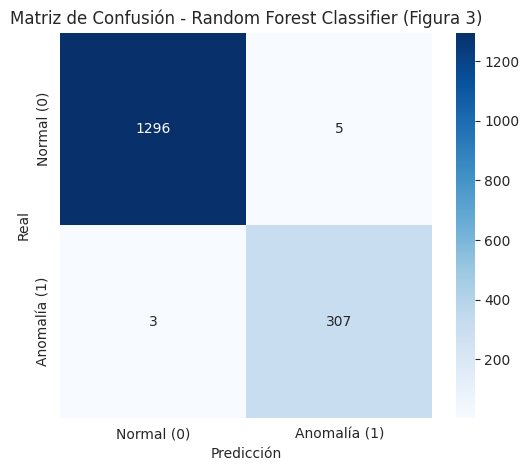


REPORTE DE CLASIFICACIÓN - RANDOM FOREST
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1301
    Anomalía       0.98      0.99      0.99       310

    accuracy                           1.00      1611
   macro avg       0.99      0.99      0.99      1611
weighted avg       1.00      1.00      1.00      1611



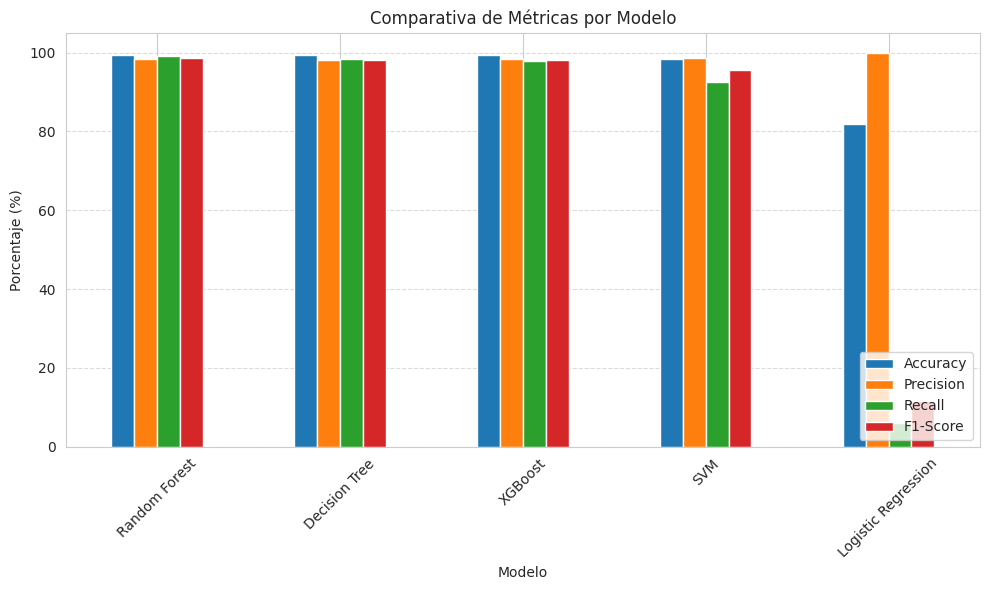


🏆 El mejor modelo en Accuracy es: Random Forest con un 99.50%


In [ ]:
# =============================================
# EVALUACIÓN DE LOS 5 MODELOS
# (Basado en la Sección 3 y Tabla 2 del artículo)
# =============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Diccionario para almacenar los resultados
results = {}

print("=== EVALUANDO MODELOS ===\n")
for name, model in trained_models.items():
    # Predecir sobre el conjunto de prueba
    y_pred = model.predict(X_test_scaled)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Guardar en el diccionario
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

    print(f"{name:20} -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

# 2. Crear DataFrame con los resultados (en porcentaje)
results_df = pd.DataFrame(results).T * 100
results_df = results_df.round(2)

print("\n" + "="*60)
print("TABLA DE RESULTADOS (en %) - Similar a la Tabla 2 del artículo")
print("="*60)
print(results_df)

# 3. Matriz de confusión para el mejor modelo (Random Forest)
#    (Figura 3 del artículo)
best_model = trained_models['Random Forest']
y_pred_rf = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomalía (1)'],
            yticklabels=['Normal (0)', 'Anomalía (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest Classifier (Figura 3)')
plt.show()

# 4. Reporte detallado de clasificación para Random Forest
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN - RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomalía']))

# 5. (Opcional) Gráfica de barras comparativa de métricas por modelo
fig, ax = plt.subplots(figsize=(10, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax)
ax.set_title('Comparativa de Métricas por Modelo')
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Modelo')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. (Extra) ¿Cuál fue el mejor modelo en Accuracy?
best_model_name = results_df['Accuracy'].idxmax()
best_accuracy = results_df.loc[best_model_name, 'Accuracy']
print(f"\n🏆 El mejor modelo en Accuracy es: {best_model_name} con un {best_accuracy:.2f}%")

In [ ]:
# =============================================
# TABLA COMPARATIVA LEGIBLE POR MÉTRICA
# =============================================

import pandas as pd

# Datos del artículo (Tabla 2) - ya definidos antes
article_data = {
    'Accuracy': [99, 94, 97, 89, 85],
    'Precision': [98, 92, 95, 87, 83],
    'Recall': [99, 94, 96, 88, 84],
    'F1-Score': [98.5, 93, 95.5, 87.5, 83.5]
}
article_df = pd.DataFrame(article_data,
                          index=['Random Forest', 'Decision Tree', 'XGBoost', 'SVM', 'Logistic Regression'])

# Asegurar que results_df existe y tiene los índices correctos
if 'results_df' not in globals():
    print(" Error: 'results_df' no encontrado. Asegúrate de haber ejecutado el entrenamiento primero.")
else:
    # Reordenar para que coincida con el artículo
    order = ['Random Forest', 'Decision Tree', 'XGBoost', 'SVM', 'Logistic Regression']
    user_df = results_df.loc[order]
    article_df = article_df.loc[order]  # reordenar también el artículo por seguridad

    print("\n" + "="*80)
    print(" COMPARACIÓN DE RESULTADOS: TU EJECUCIÓN vs. ARTÍCULO (Tabla 2)")
    print("="*80)

    # Mostrar tabla por métrica
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        print(f"\n{'='*40}")
        print(f" {metric}")
        print('='*40)

        # Crear DataFrame con User, Article, Diff
        df_metric = pd.DataFrame({
            'Modelo': order,
            'User': user_df[metric].values,
            'Article': article_df[metric].values,
            'Diff': user_df[metric].values - article_df[metric].values
        })
        print(df_metric.round(2))

    # Resumen global: diferencia promedio por modelo
    print("\n" + "="*80)
    print(" RESUMEN: DIFERENCIA ABSOLUTA PROMEDIO POR MODELO")
    print("="*80)

    # Calcular la diferencia absoluta promedio para cada modelo (todas las métricas)
    diff_abs_mean = pd.DataFrame(index=order)
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        diff_abs_mean[metric] = (user_df[metric] - article_df[metric]).abs()
    diff_abs_mean['Promedio'] = diff_abs_mean.mean(axis=1)

    print(diff_abs_mean.round(2))

    # Mejor modelo (el que más se acerca al artículo)
    best_model = diff_abs_mean['Promedio'].idxmin()
    best_value = diff_abs_mean.loc[best_model, 'Promedio']
    print(f"\n El modelo que más se acerca al artículo es: **{best_model}** (diferencia promedio de {best_value:.2f} puntos)")

    # Interpretación
    print("\n" + "="*80)
    print(" INTERPRETACIÓN")
    print("="*80)
    if best_value < 2:
        print(" Excelente: tus resultados son casi idénticos a los del artículo.")
    elif best_value < 5:
        print(" Muy bueno: tus resultados son muy cercanos a los del artículo.")
    elif best_value < 10:
        print(" Aceptable: hay diferencias moderadas. Puede deberse a la falta de variables adicionales (frecuencia, THD, etc.).")
    else:
        print(" Diferencias significativas. Revisa el preprocesamiento o considera añadir más características.")


 COMPARACIÓN DE RESULTADOS: TU EJECUCIÓN vs. ARTÍCULO (Tabla 2)

 Accuracy
                Modelo   User  Article  Diff
0        Random Forest  99.50       99  0.50
1        Decision Tree  99.32       94  5.32
2              XGBoost  99.26       97  2.26
3                  SVM  98.32       89  9.32
4  Logistic Regression  81.94       85 -3.06

 Precision
                Modelo    User  Article   Diff
0        Random Forest   98.40       98   0.40
1        Decision Tree   98.07       92   6.07
2              XGBoost   98.38       95   3.38
3                  SVM   98.63       87  11.63
4  Logistic Regression  100.00       83  17.00

 Recall
                Modelo   User  Article   Diff
0        Random Forest  99.03       99   0.03
1        Decision Tree  98.39       94   4.39
2              XGBoost  97.74       96   1.74
3                  SVM  92.58       88   4.58
4  Logistic Regression   6.13       84 -77.87

 F1-Score
                Modelo   User  Article   Diff
0        Random Fo